In [1]:
import pandas as pd

# Carregando as tabelas principais
pedidos = pd.read_csv('dados/olist_orders_dataset.csv')
clientes = pd.read_csv('dados/olist_customers_dataset.csv')
itens = pd.read_csv('dados/olist_order_items_dataset.csv')

# Visualizando as primeiras linhas de cada tabela
print("=== PEDIDOS ===")
print(pedidos.head())

print("\n=== CLIENTES ===")
print(clientes.head())

print("\n=== ITENS ===")
print(itens.head())

=== PEDIDOS ===
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00  

In [2]:
print("Tamanho das tabelas:")
print(f"Pedidos:  {pedidos.shape[0]} linhas x {pedidos.shape[1]} colunas")
print(f"Clientes: {clientes.shape[0]} linhas x {clientes.shape[1]} colunas")
print(f"Itens:    {itens.shape[0]} linhas x {itens.shape[1]} colunas")

Tamanho das tabelas:
Pedidos:  99441 linhas x 8 colunas
Clientes: 99441 linhas x 5 colunas
Itens:    112650 linhas x 7 colunas


In [3]:
pedidos.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [4]:
itens.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [7]:
colunas_data = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for coluna in colunas_data:
    pedidos[coluna] = pd.to_datetime(pedidos[coluna])

pedidos.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [8]:
status = pedidos['order_status'].value_counts()
print(status)

print("\nEm porcentagem:")
print(round(status / len(pedidos) * 100, 2))

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Em porcentagem:
order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: count, dtype: float64


In [9]:
# Extraindo o mês/ano da data de compra
pedidos['mes_ano'] = pedidos['order_purchase_timestamp'].dt.to_period('M')

# Contando pedidos por mês
pedidos_por_mes = pedidos.groupby('mes_ano').size()
print(pedidos_por_mes)

mes_ano
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64


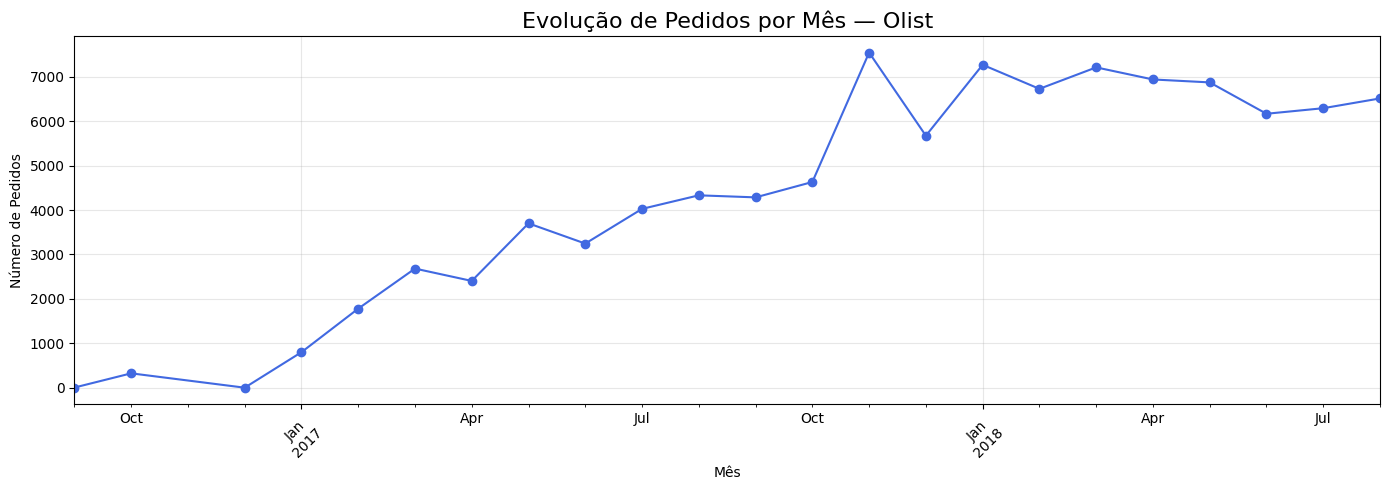

In [10]:
import matplotlib.pyplot as plt

# Convertendo para formato que o matplotlib entende
pedidos_por_mes_plot = pedidos_por_mes[:-2]  # removendo os 2 últimos meses incompletos

plt.figure(figsize=(14, 5))
pedidos_por_mes_plot.plot(kind='line', marker='o', color='royalblue')

plt.title('Evolução de Pedidos por Mês — Olist', fontsize=16)
plt.xlabel('Mês')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

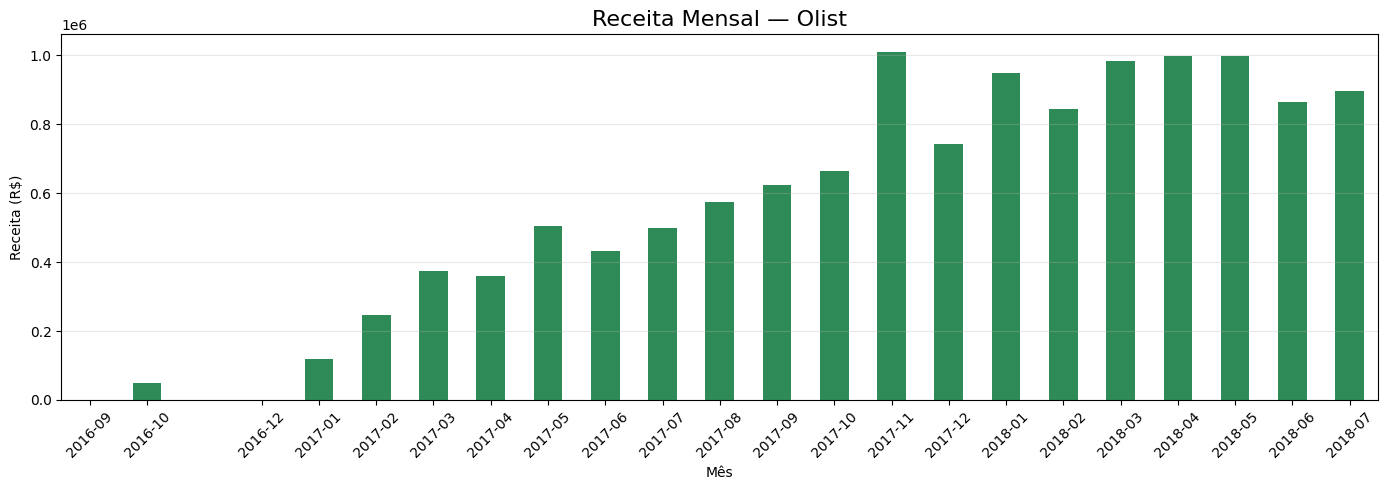

In [11]:
# Unindo pedidos com itens pelo order_id
df = pedidos.merge(itens, on='order_id', how='inner')

# Calculando receita por mês
df['mes_ano'] = df['order_purchase_timestamp'].dt.to_period('M')
receita_mensal = df.groupby('mes_ano')['price'].sum()[:-2]

# Gráfico de receita
plt.figure(figsize=(14, 5))
receita_mensal.plot(kind='bar', color='seagreen')

plt.title('Receita Mensal — Olist', fontsize=16)
plt.xlabel('Mês')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

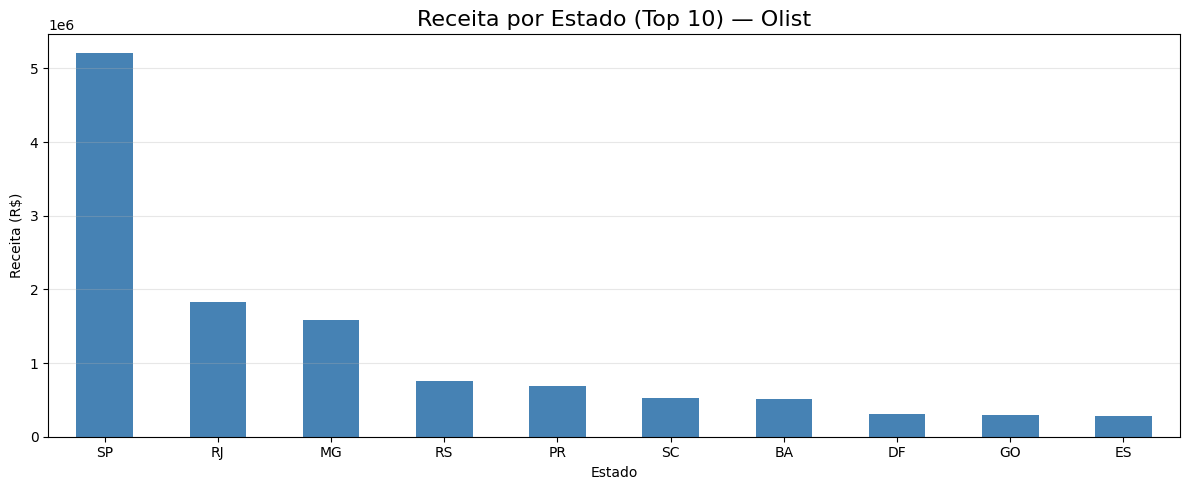

In [12]:
# Unindo com clientes para pegar o estado
df_completo = df.merge(clientes, on='customer_id', how='inner')

# Top 10 estados por receita
receita_por_estado = df_completo.groupby('customer_state')['price'].sum().sort_values(ascending=False).head(10)

# Gráfico
plt.figure(figsize=(12, 5))
receita_por_estado.plot(kind='bar', color='steelblue')

plt.title('Receita por Estado (Top 10) — Olist', fontsize=16)
plt.xlabel('Estado')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

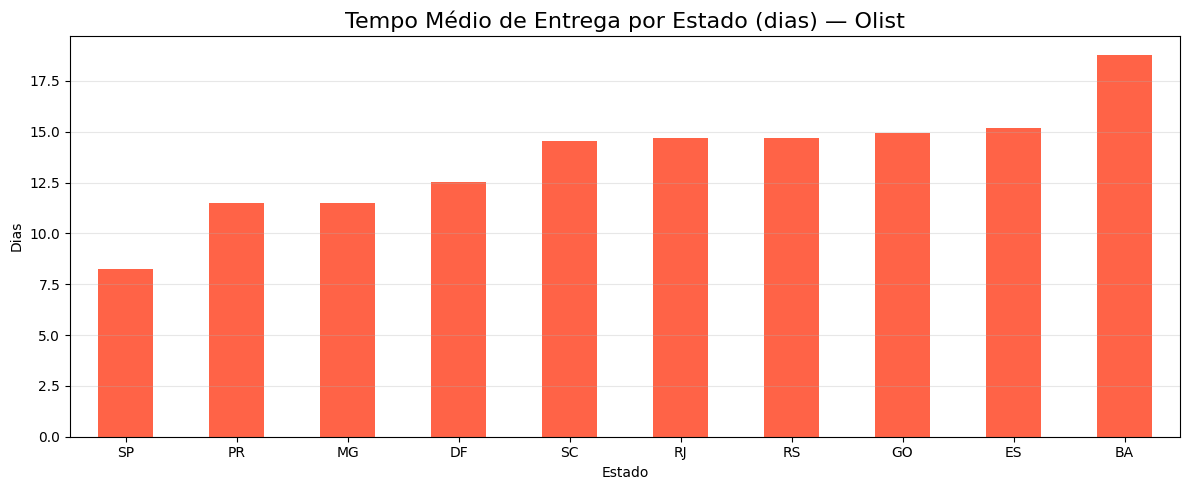

In [13]:
# Calculando tempo de entrega em dias
df_completo['tempo_entrega'] = (
    df_completo['order_delivered_customer_date'] - 
    df_completo['order_purchase_timestamp']
).dt.days

# Removendo pedidos sem data de entrega (cancelados etc.)
df_entregues = df_completo.dropna(subset=['tempo_entrega'])

# Média por estado (top 10 que mais compram)
estados_top = receita_por_estado.index.tolist()
tempo_por_estado = (
    df_entregues[df_entregues['customer_state'].isin(estados_top)]
    .groupby('customer_state')['tempo_entrega']
    .mean()
    .sort_values()
)

# Gráfico
plt.figure(figsize=(12, 5))
tempo_por_estado.plot(kind='bar', color='tomato')

plt.title('Tempo Médio de Entrega por Estado (dias) — Olist', fontsize=16)
plt.xlabel('Estado')
plt.ylabel('Dias')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 📊 Análise de Vendas — Olist

## Sobre o dataset
- 99.441 pedidos reais de e-commerce brasileiro (2016–2018)
- Fonte: Kaggle / Olist

## Principais Insights

### 1. Crescimento
- A Olist cresceu de 4 pedidos/mês (Set/2016) para ~7.500/mês (Nov/2017)
- Crescimento de mais de 1.800x em pouco mais de um ano

### 2. Receita
- Pico de receita em Nov/2017: ~R$ 1.000.000 em um único mês
- Ticket médio geral: R$ 120,65

### 3. Distribuição geográfica
- SP concentra quase 3x mais receita que o 2º colocado (RJ)
- Sudeste domina as vendas (SP + RJ + MG)

### 4. Logística
- SP entrega em ~8 dias (mais rápido)
- BA entrega em ~18 dias (mais lento) — oportunidade de melhoria